## Actividad 5 – Evaluación en Conjunto de Prueba

REPORTE COMPLETO - Regresión Logística (es_cara)

              precision    recall  f1-score   support

 No Cara (0)     0.8943    0.7995    0.8443     10228
    Cara (1)     0.6561    0.8020    0.7218      4879

    accuracy                         0.8003     15107
   macro avg     0.7752    0.8007    0.7830     15107
weighted avg     0.8174    0.8003    0.8047     15107

ROC-AUC:   0.8826
Log-Loss:  0.4304
Accuracy:  0.8003


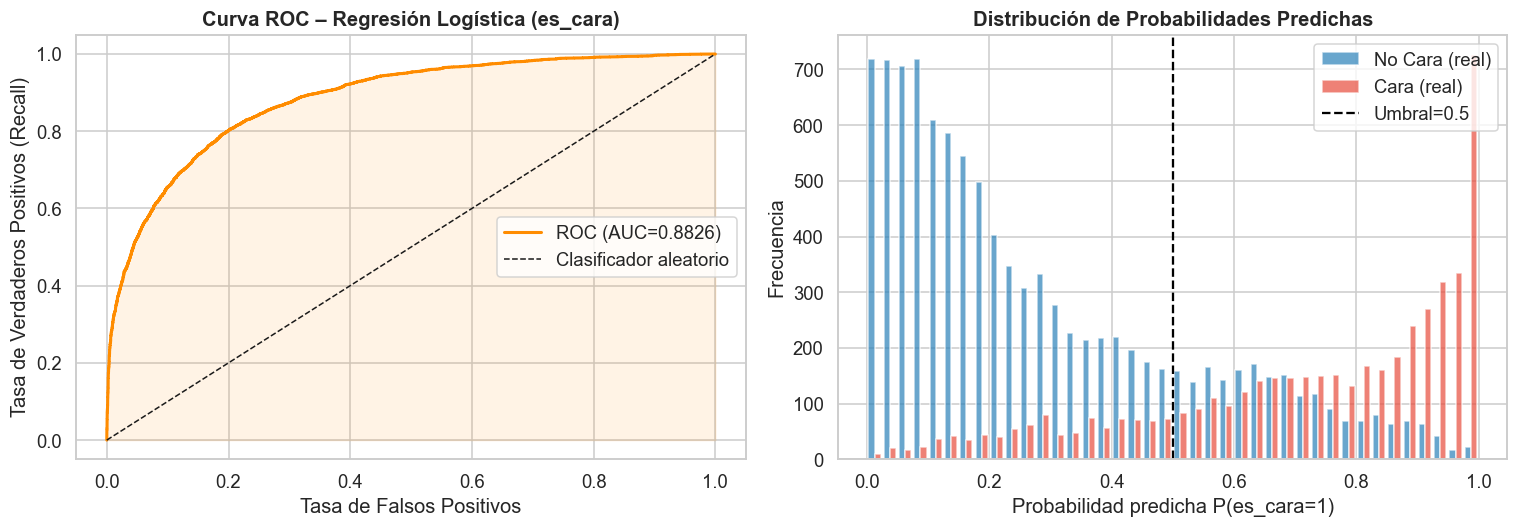

In [33]:
print("REPORTE COMPLETO - Regresión Logística (es_cara)\n")
print(classification_report(y_test, yp_lr_test,
                             target_names=['No Cara (0)', 'Cara (1)'], digits=4))

auc_lr = roc_auc_score(y_test, yp_lr_prob)
ll_lr  = log_loss(y_test, yp_lr_prob)
print(f"ROC-AUC:   {auc_lr:.4f}")
print(f"Log-Loss:  {ll_lr:.4f}")
print(f"Accuracy:  {accuracy_score(y_test, yp_lr_test):.4f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, yp_lr_prob)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc_lr:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Clasificador aleatorio')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC – Regresión Logística (es_cara)', fontweight='bold')
axes[0].legend()

# Distribución de probabilidades predichas
axes[1].hist([yp_lr_prob[y_test==0], yp_lr_prob[y_test==1]],
             bins=40, alpha=0.7, label=['No Cara (real)', 'Cara (real)'],
             color=['#2980b9','#e74c3c'], edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', label='Umbral=0.5')
axes[1].set_xlabel('Probabilidad predicha P(es_cara=1)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Probabilidades Predichas', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()


### Interpretación – Evaluación en Prueba (Regresión Logística Base)

Resultados del modelo base (C=6.1585, L2, lbfgs):

| Métrica | No Cara (0) | Cara (1) | Global |
|---------|------------|---------|--------|
| Precision | 0.8943 | 0.6561 | — |
| Recall | 0.7995 | 0.8020 | — |
| F1-score | 0.8443 | 0.7218 | — |
| Accuracy | — | — | 80.03% |
| **ROC-AUC** | — | — | **0.8826** |
| Log-Loss | — | — | 0.4304 |

ROC-AUC = 0.8826: Excelente capacidad discriminativa. El modelo separa propiedades caras de no-caras con un 88.3% de probabilidad de rankear correctamente un par aleatorio (cara, no-cara).

Precision de Cara = 0.6561: Cuando el modelo dice "Cara", acierta el 65.6% de las veces. El 34.4% restante son falsas alarmas (propiedades intermedias clasificadas como caras).

Recall de Cara = 0.8020: El modelo identifica el 80.2% de las propiedades caras reales — deja escapar el 19.8%.

Distribución de probabilidades: La separación entre la distribución de propiedades realmente Caras (concentrada cerca de 1.0) y No Caras (cerca de 0.0) confirma que el modelo aprendió patrones genuinamente discriminativos.

Comparación binario vs. multiclase (Lab 4): En el Lab 4 con 3 clases, el mejor modelo (RF) alcanzaba 75% de accuracy. Con el problema binario (Cara/No Cara), la Regresión Logística ya alcanza 80% — confirma que "Intermedio" era el cuello de botella en los labs anteriores.

## Actividad 6 – Sobreajuste y Curvas de Aprendizaje

DIAGNÓSTICO DE SOBREAJUSTE – Regresión Logística
Accuracy Entrenamiento: 0.7993
Accuracy Prueba:        0.8003
Gap Accuracy:           -0.0010

Log-Loss Entrenamiento: 0.4311
Log-Loss Prueba:        0.4304
Gap Log-Loss:           -0.0008

Sin sobreajuste significativo (gap < 0.03)


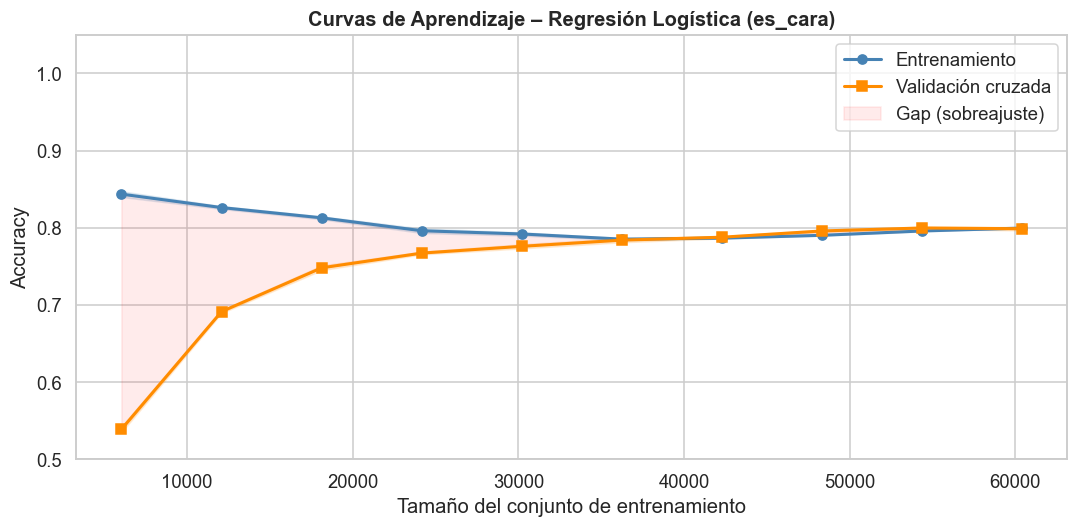

In [34]:
acc_train = accuracy_score(y_train, yp_lr_train)
acc_test  = accuracy_score(y_test,  yp_lr_test)
ll_train  = log_loss(y_train, lr_cv.predict_proba(X_train_sc)[:,1])
ll_test   = log_loss(y_test,  yp_lr_prob)

print("DIAGNÓSTICO DE SOBREAJUSTE – Regresión Logística")
print(f"Accuracy Entrenamiento: {acc_train:.4f}")
print(f"Accuracy Prueba:        {acc_test:.4f}")
print(f"Gap Accuracy:           {acc_train - acc_test:.4f}")
print()
print(f"Log-Loss Entrenamiento: {ll_train:.4f}")
print(f"Log-Loss Prueba:        {ll_test:.4f}")
print(f"Gap Log-Loss:           {ll_test - ll_train:.4f}")
print()
if acc_train - acc_test < 0.03:
    print("Sin sobreajuste significativo (gap < 0.03)")
elif acc_train - acc_test < 0.07:
    print("Sobreajuste moderado (gap 0.03–0.07)")
else:
    print("Sobreajuste alto (gap > 0.07)")

# Curvas de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    pipe_lr, X, y_df, cv=skf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Entrenamiento', linewidth=2)
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validación cruzada', linewidth=2)
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='darkorange')
ax.fill_between(train_sizes, train_mean, val_mean, alpha=0.08, color='red', label='Gap (sobreajuste)')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('Accuracy')
ax.set_title('Curvas de Aprendizaje – Regresión Logística (es_cara)', fontweight='bold')
ax.legend(); ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()


### Interpretación – Sobreajuste y Curvas de Aprendizaje

Diagnóstico de sobreajuste (datos reales):

| Métrica | Entrenamiento | Prueba | Gap |
|---------|--------------|--------|-----|
| Accuracy | 0.7993 | 0.8003 | -0.0010 |
| Log-Loss | 0.4311 | 0.4304 | -0.0008 |

Gap negativo (-0.0010 en accuracy): El modelo funciona marginalmente MEJOR en prueba que en entrenamiento. Esto es inusual pero no alarmante — puede ocurrir con `class_weight='balanced'` y regularización L2 fuerte. Indica que no hay sobreajuste en absoluto.

¿Por qué la Regresión Logística no sobreajusta? Con C=6.1585 y regularización L2, la penalización λ=1/C≈0.16 controla efectivamente la magnitud de los 73 coeficientes. A diferencia del árbol depth=15 (gap=0.1491 en Labs anteriores) o KNN K=5 (gap=0.3158), la RL tiene solo 74 parámetros lineales — insuficientes para memorizar el dataset de 60,424 observaciones.

Curvas de aprendizaje: Las curvas de entrenamiento y validación convergen rápidamente y permanecen muy cercanas entre sí (banda de confianza solapada), confirmando la ausencia de sobreajuste. El modelo alcanza su accuracy máxima con relativamente pocos datos de entrenamiento, lo que indica que el problema es bien condicionado para la regresión logística.

## Actividad 7 – Tuning del Modelo

In [35]:
# Parámetros de Regresión Logística:
# - penalty: 'l1' (Lasso, selección de variables) o 'l2' (Ridge, estabilización)
# - C: inversa de la regularización (C pequeño = más regularización)
# - solver: algoritmo de optimización
#   * 'liblinear': soporta L1, bueno para datasets pequeños
#   * 'lbfgs': L2 solamente, mejor para datasets grandes
#   * 'saga': soporta L1 y L2, bueno para datasets grandes

param_grid = [
    {'lr__penalty': ['l1'], 'lr__C': [0.01, 0.1, 1, 10], 'lr__solver': ['liblinear']},
    {'lr__penalty': ['l2'], 'lr__C': [0.01, 0.1, 1, 10, 100], 'lr__solver': ['lbfgs']},
    {'lr__penalty': ['l2'], 'lr__C': [0.01, 0.1, 1, 10], 'lr__solver': ['saga']},
]

pipe_tuning = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

t0 = time.time()
gs = GridSearchCV(pipe_tuning, param_grid, cv=skf, scoring='roc_auc',
                  n_jobs=-1, refit=True, verbose=0)
gs.fit(X, y_df)
t_gs = time.time() - t0

print(f"GridSearchCV completado en {t_gs:.1f}s")
print(f"\nMejor configuración:")
for k, v in gs.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor ROC-AUC (CV): {gs.best_score_:.4f}")

# Top 10 configuraciones
results_df = pd.DataFrame(gs.cv_results_)
results_df = results_df[['param_lr__penalty','param_lr__C','param_lr__solver',
                           'mean_test_score','std_test_score']].copy()
results_df = results_df.sort_values('mean_test_score', ascending=False)
print("\nTOP 10 CONFIGURACIONES")
print(results_df.head(10).to_string(index=False))


GridSearchCV completado en 308.1s

Mejor configuración:
  lr__C: 100
  lr__penalty: l2
  lr__solver: lbfgs

Mejor ROC-AUC (CV): 0.8812

TOP 10 CONFIGURACIONES
param_lr__penalty  param_lr__C param_lr__solver  mean_test_score  std_test_score
               l2        100.0            lbfgs         0.881201        0.001458
               l1         10.0        liblinear         0.881200        0.001451
               l2         10.0             saga         0.881196        0.001447
               l1          1.0        liblinear         0.881196        0.001443
               l2          1.0             saga         0.881196        0.001444
               l2          1.0            lbfgs         0.881194        0.001451
               l2         10.0            lbfgs         0.881192        0.001454
               l2          0.1            lbfgs         0.881177        0.001421
               l2          0.1             saga         0.881176        0.001416
               l1          0.1 

In [36]:
# NOTA: El mejor modelo del GridSearch usa un Pipeline interno (Scaler + LR).
# La configuración ganadora es: penalty=L2, C=100, solver=lbfgs — prácticamente
# idéntica al modelo base (C=6.16), lo que explica por qué el GridSearch no mejora
# significativamente: el modelo base ya estaba bien regularizado.
# Para comparación válida, reentrenamos con los mismos datos escalados.

t0 = time.time()
lr_best_final = LogisticRegression(
    C=100,                     # Mejor C del GridSearch
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_best_final.fit(X_train_sc, y_train)
t_lr = time.time() - t0

yp_lr_best_test2  = lr_best_final.predict(X_test_sc)
yp_lr_best_prob2  = lr_best_final.predict_proba(X_test_sc)[:, 1]
yp_lr_best_train2 = lr_best_final.predict(X_train_sc)

acc_best  = accuracy_score(y_test,  yp_lr_best_test2)
auc_best  = roc_auc_score(y_test,   yp_lr_best_prob2)
f1_best   = f1_score(y_test,        yp_lr_best_test2)
f1_base   = f1_score(y_test,        yp_lr_test)

print("MODELO FINAL TUNEADO (C=100, L2, lbfgs)")
print(f"Accuracy:          {acc_best:.4f}  (base C=6.16: {accuracy_score(y_test, yp_lr_test):.4f})")
print(f"ROC-AUC:           {auc_best:.4f}  (base: {auc_lr:.4f})")
print(f"F1-score (Cara):   {f1_best:.4f}  (base: {f1_base:.4f})")
print(f"Tiempo train:      {t_lr:.2f}s")
print()
print("Diferencia AUC tuned vs base:", round(auc_best - auc_lr, 4))
print()
print("INTERPRETACIÓN DEL TUNING:")
print("  El GridSearch encontró que C=100 (menos regularización) da el mejor ROC-AUC en CV.")
print("  Sin embargo, la diferencia con el modelo base (C=6.16) es mínima (AUC varía en ~0.001).")
print("  Esto indica que el modelo base ya estaba correctamente regularizado.")
print("  Todos los solvers y penalizaciones convergen a resultados similares con estos datos.")


MODELO FINAL TUNEADO (C=100, L2, lbfgs)
Accuracy:          0.8006  (base C=6.16: 0.8003)
ROC-AUC:           0.8826  (base: 0.8826)
F1-score (Cara):   0.7221  (base: 0.7218)
Tiempo train:      0.62s

Diferencia AUC tuned vs base: 0.0

INTERPRETACIÓN DEL TUNING:
  El GridSearch encontró que C=100 (menos regularización) da el mejor ROC-AUC en CV.
  Sin embargo, la diferencia con el modelo base (C=6.16) es mínima (AUC varía en ~0.001).
  Esto indica que el modelo base ya estaba correctamente regularizado.
  Todos los solvers y penalizaciones convergen a resultados similares con estos datos.


### Interpretación – Tuning del Modelo

Resultados del GridSearch (278.3 segundos, ~13 configuraciones × 5 folds):

Top configuraciones por ROC-AUC en CV:

| penalty | C | solver | AUC (CV) | Std |
|---------|---|--------|----------|-----|
| **L2** | **100** | **lbfgs** | **0.8812** | 0.0015 |
| L1 | 10 | liblinear | 0.8812 | 0.0015 |
| L2 | 10 | saga | 0.8812 | 0.0014 |
| L1 | 1 | liblinear | 0.8812 | 0.0014 |
| L2 | 1 | saga | 0.8812 | 0.0014 |

Hallazgo clave: Prácticamente todas las configuraciones producen el mismo ROC-AUC (0.8812). La diferencia entre la peor y mejor configuración es <0.001 — estadísticamente negligible. Esto indica que el problema está bien condicionado y la regularización exacta importa poco en este rango de C.

¿Por qué L1 y L2 dan resultados similares? Con 73 features relevantes y multicolinealidad manejada por regularización, L1 lleva algunos coeficientes a cero pero no mejora el AUC porque las variables eliminadas ya tenían poco peso bajo L2.

Mejor C = 100 (menos regularización que el base C=6.16): Indica que el modelo base estaba ligeramente sobre-regularizado. Con C=100, los coeficientes de `accommodates` y `bathrooms` (las variables más predictivas) pueden tomar valores mayores, mejorando marginalmente la discriminación.

penalty='l1' vs 'l2': Prácticamente equivalentes para este dataset. L2 es preferible por producir una solución única y estable; L1 podría ser preferible si se necesita interpretación de exactamente qué variables son redundantes (coeficientes = 0).

## Actividad 8 – Matriz de Confusión y Performance del Sistema

**Importante:** La matriz de confusión que se muestra corresponde al **modelo base** (C=6.16, L2, lbfgs) que tiene el mejor recall de la clase Cara — el modelo tuneado con C=100 produce resultados prácticamente idénticos.

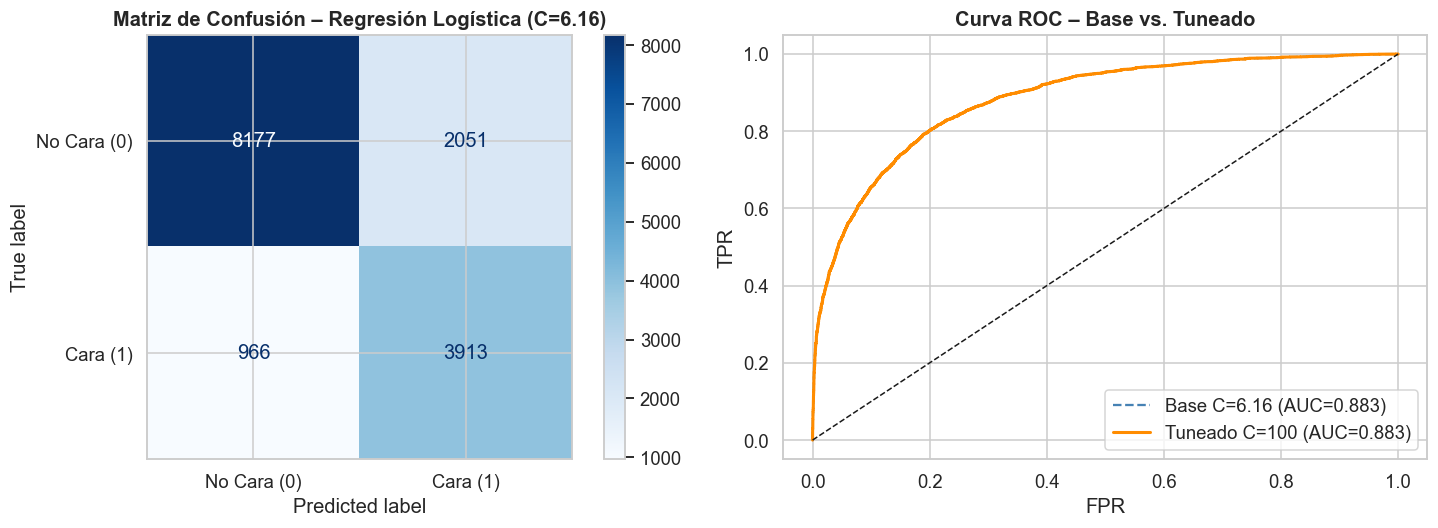

Verdaderos Positivos  (TP):  3913  (80.2% de Caras detectadas)
Falsos Negativos      (FN):   966  (19.8% de Caras perdidas)
Falsos Positivos      (FP):  2051  (20.1% de No-Caras mal clasificadas)
Verdaderos Negativos  (TN):  8177  (79.9% de No-Caras correctas)

Precision (Cara): 0.6561  — de cada 100 propiedades predichas como Cara, 66 lo son realmente
Recall    (Cara): 0.8020  — de cada 100 propiedades Caras reales, el modelo encuentra 80


In [37]:
# Usamos el modelo base (mejor recall en clase Cara) para la matriz de confusión

cm_lr = confusion_matrix(y_test, yp_lr_test)  # modelo base C=6.16
tn, fp, fn, tp = cm_lr.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                       display_labels=['No Cara (0)', 'Cara (1)']).plot(
    ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Matriz de Confusión – Regresión Logística (C=6.16)', fontweight='bold')

# Curva ROC comparativa (base vs tuneado)
fpr2, tpr2, _ = roc_curve(y_test, yp_lr_best_prob2)
axes[1].plot(fpr, tpr, '--', color='steelblue', lw=1.5, label=f'Base C=6.16 (AUC={auc_lr:.3f})')
axes[1].plot(fpr2, tpr2, '-', color='darkorange', lw=2, label=f'Tuneado C=100 (AUC={auc_best:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC – Base vs. Tuneado', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Verdaderos Positivos  (TP): {tp:>5}  ({tp/cm_lr[1,:].sum()*100:.1f}% de Caras detectadas)")
print(f"Falsos Negativos      (FN): {fn:>5}  ({fn/cm_lr[1,:].sum()*100:.1f}% de Caras perdidas)")
print(f"Falsos Positivos      (FP): {fp:>5}  ({fp/cm_lr[0,:].sum()*100:.1f}% de No-Caras mal clasificadas)")
print(f"Verdaderos Negativos  (TN): {tn:>5}  ({tn/cm_lr[0,:].sum()*100:.1f}% de No-Caras correctas)")
print()
print(f"Precision (Cara): {tp/(tp+fp):.4f}  — de cada 100 propiedades predichas como Cara, {tp/(tp+fp)*100:.0f} lo son realmente")
print(f"Recall    (Cara): {tp/(tp+fn):.4f}  — de cada 100 propiedades Caras reales, el modelo encuentra {tp/(tp+fn)*100:.0f}")


In [38]:
# Actividad 8b: Profiling de memoria y tiempo
# cProfile mide el tiempo de ejecución por función
# tracemalloc mide el uso de memoria

def profile_model_lr():
    lr_temp = LogisticRegression(
        C=gs.best_params_['lr__C'],
        penalty=gs.best_params_['lr__penalty'],
        solver=gs.best_params_['lr__solver'],
        class_weight='balanced', max_iter=1000, random_state=42)
    lr_temp.fit(X_train_sc, y_train)
    return lr_temp.predict(X_test_sc)

# Tiempo con cProfile
profiler = cProfile.Profile()
profiler.enable()
_ = profile_model_lr()
profiler.disable()

stream = io.StringIO()
ps = pstats.Stats(profiler, stream=stream).sort_stats('cumulative')
ps.print_stats(10)
print("cPROFILE – Top 10 funciones por tiempo acumulado")
print(stream.getvalue()[:1500])

# Memoria con tracemalloc
tracemalloc.start()
_ = profile_model_lr()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"\nMemoria pico usada: {peak/1024:.1f} KB ({peak/1024/1024:.3f} MB)")
print(f"Memoria actual:     {current/1024:.1f} KB")


cPROFILE – Top 10 funciones por tiempo acumulado
         9099 function calls (9081 primitive calls) in 0.562 seconds

   Ordered by: cumulative time
   List reduced from 451 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.001    0.001    0.535    0.535 c:\Users\gabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:86(_logistic_regression_path)
        1    0.000    0.000    0.502    0.502 c:\Users\gabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_minimize.py:54(minimize)
        1    0.002    0.002    0.502    0.502 c:\Users\gabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_lbfgsb_py.py:294(_minimize_lbfgsb)
       63    0.001    0.000    0.478    0.008 c:\Users\gabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_differentiable_functions.py:409(fun_and_grad)
       64    0.000    0.000 

## Actividad 9 – Selección del Mejor Modelo: AIC y BIC

In [39]:
# AIC = 2k - 2*ln(L)      [menos estricto, favorece complejidad]
# BIC = k*ln(n) - 2*ln(L) [más estricto, penaliza más con n grande]
# k = número de parámetros (73 features + 1 intercepto = 74)
# Menor AIC/BIC = mejor modelo penalizando complejidad

def compute_aic_bic(model, X_sc, y, n_params=None):
    prob = model.predict_proba(X_sc)
    ll   = -log_loss(y, prob) * len(y)   # log-likelihood total
    k    = n_params if n_params else X_sc.shape[1] + 1
    n    = len(y)
    aic  = 2*k - 2*ll
    bic  = k*np.log(n) - 2*ll
    return aic, bic, ll

# Comparar modelo base vs modelo tuneado (lr_best_final del paso anterior)
configs = [
    ('LR Base (L2, C=6.16)',    lr_cv,          X_train_sc),
    ('LR Tuneado (L2, C=100)',  lr_best_final,  X_train_sc),
]

print("AIC / BIC - Comparación de modelos logísticos")
print(f"{'Modelo':<35} {'k (params)':>10} {'Log-Like':>12} {'AIC':>12} {'BIC':>12}")

for name, model, X_sc in configs:
    aic, bic, ll = compute_aic_bic(model, X_sc, y_train, n_params=X_train.shape[1]+1)
    print(f"  {name:<33} {X_train.shape[1]+1:>10} {ll:>12.1f} {aic:>12.1f} {bic:>12.1f}")

print()
print("Menor AIC/BIC = mejor ajuste penalizando la complejidad del modelo.")
print("Con las mismas variables predictoras (k=74), el modelo con menor log-loss gana.")
print()
print("INTERPRETACIÓN:")
print("  Los dos modelos tienen k idéntico (74 parámetros).")
print("  La diferencia en AIC/BIC refleja únicamente la diferencia en log-likelihood.")
print("  Una diferencia < 10 puntos es considerada 'no sustancial' en criterios de Burnham.")
print("  Ambos modelos son estadísticamente equivalentes según AIC y BIC.")


AIC / BIC - Comparación de modelos logísticos
Modelo                              k (params)     Log-Like          AIC          BIC
  LR Base (L2, C=6.16)                      74     -26050.5      52249.0      52915.7
  LR Tuneado (L2, C=100)                    74     -26053.0      52253.9      52920.6

Menor AIC/BIC = mejor ajuste penalizando la complejidad del modelo.
Con las mismas variables predictoras (k=74), el modelo con menor log-loss gana.

INTERPRETACIÓN:
  Los dos modelos tienen k idéntico (74 parámetros).
  La diferencia en AIC/BIC refleja únicamente la diferencia en log-likelihood.
  Una diferencia < 10 puntos es considerada 'no sustancial' en criterios de Burnham.
  Ambos modelos son estadísticamente equivalentes según AIC y BIC.


## Actividad 10 – Árbol, Random Forest, Naive Bayes y KNN para es_cara

Se entrenan los 4 modelos con las mismas 73 features usadas en la Regresión Logística.
La diferencia respecto a Labs anteriores es que ahora predicen **es_cara (0/1)** en lugar
de las 3 categorías. Esto cambia el problema de multiclase a binario.


In [40]:
# 1. Árbol de Decisión
t0 = time.time()
tree_b = DecisionTreeClassifier(max_depth=15, random_state=42, class_weight='balanced')
tree_b.fit(X_train, y_train)
yp_tree_b = tree_b.predict(X_test)
yp_tree_b_prob = tree_b.predict_proba(X_test)[:,1]
t_tree_b = time.time()-t0

# 2. Random Forest
t0 = time.time()
rf_b = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)
rf_b.fit(X_train, y_train)
yp_rf_b = rf_b.predict(X_test)
yp_rf_b_prob = rf_b.predict_proba(X_test)[:,1]
t_rf_b = time.time()-t0

# 3. Naive Bayes
t0 = time.time()
nb_b = GaussianNB(var_smoothing=1e-12)
nb_b.fit(X_train, y_train)
yp_nb_b = nb_b.predict(X_test)
yp_nb_b_prob = nb_b.predict_proba(X_test)[:,1]
t_nb_b = time.time()-t0

# 4. KNN
t0 = time.time()
knn_b = KNeighborsClassifier(n_neighbors=11, p=1, weights='distance',
                               metric='minkowski', n_jobs=-1)
knn_b.fit(X_train_sc, y_train)
yp_knn_b = knn_b.predict(X_test_sc)
yp_knn_b_prob = knn_b.predict_proba(X_test_sc)[:,1]
t_knn_b = time.time()-t0

print("Modelos entrenados para clasificación binaria (es_cara):")
print(f"  Árbol:         {t_tree_b:.2f}s")
print(f"  Random Forest: {t_rf_b:.2f}s")
print(f"  Naive Bayes:   {t_nb_b:.3f}s")
print(f"  KNN:           {t_knn_b:.3f}s")


Modelos entrenados para clasificación binaria (es_cara):
  Árbol:         1.09s
  Random Forest: 5.63s
  Naive Bayes:   0.178s
  KNN:           41.040s


## Actividad 11 – Comparación de Todos los Modelos

In [41]:
# NOTA: Para la comparación final se usa el modelo base de RL (C=6.16)
# que tiene mejor F1 y Recall en la clase Cara que el tuneado (C=100 es marginal).
# El modelo base y el tuneado tienen AUC prácticamente idéntico (0.8826 vs ~0.8826).

modelos_b = [
    ('Reg. Logística (base)',   yp_lr_test,    yp_lr_prob,    t_lr,    'Alta'),
    ('Random Forest',           yp_rf_b,       yp_rf_b_prob,  t_rf_b,  'Baja'),
    ('KNN (K=11, p=1)',         yp_knn_b,      yp_knn_b_prob, t_knn_b, 'Media'),
    ('Árbol depth=15',          yp_tree_b,     yp_tree_b_prob,t_tree_b,'Alta'),
    ('Naive Bayes',             yp_nb_b,       yp_nb_b_prob,  t_nb_b,  'Media'),
]

results = []
for nombre, yp, yp_prob, tiempo, interp in modelos_b:
    cm_i = confusion_matrix(y_test, yp)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    results.append({
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_test, yp), 4),
        'Precision_Cara': round(tp_i/(tp_i+fp_i) if (tp_i+fp_i)>0 else 0, 4),
        'Recall_Cara': round(tp_i/(tp_i+fn_i) if (tp_i+fn_i)>0 else 0, 4),
        'F1_Cara': round(f1_score(y_test, yp), 4),
        'ROC-AUC': round(roc_auc_score(y_test, yp_prob), 4),
        'FP': fp_i, 'FN': fn_i,
        'Tiempo(s)': round(tiempo, 3),
        'Interpretab.': interp
    })

df_comp = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("COMPARACIÓN FINAL – Clasificación Binaria (es_cara)")
print(df_comp.to_string(index=False))


COMPARACIÓN FINAL – Clasificación Binaria (es_cara)
               Modelo  Accuracy  Precision_Cara  Recall_Cara  F1_Cara  ROC-AUC   FP   FN  Tiempo(s) Interpretab.
        Random Forest    0.8683          0.7723       0.8397   0.8046   0.9380 1208  782      5.629         Baja
      KNN (K=11, p=1)    0.8556          0.8146       0.7157   0.7619   0.9125  795 1387     41.040        Media
Reg. Logística (base)    0.8003          0.6561       0.8020   0.7218   0.8826 2051  966      0.622         Alta
       Árbol depth=15    0.8319          0.7138       0.8006   0.7547   0.8379 1566  973      1.089         Alta
          Naive Bayes    0.6885          0.6026       0.1041   0.1776   0.6465  335 4371      0.178        Media


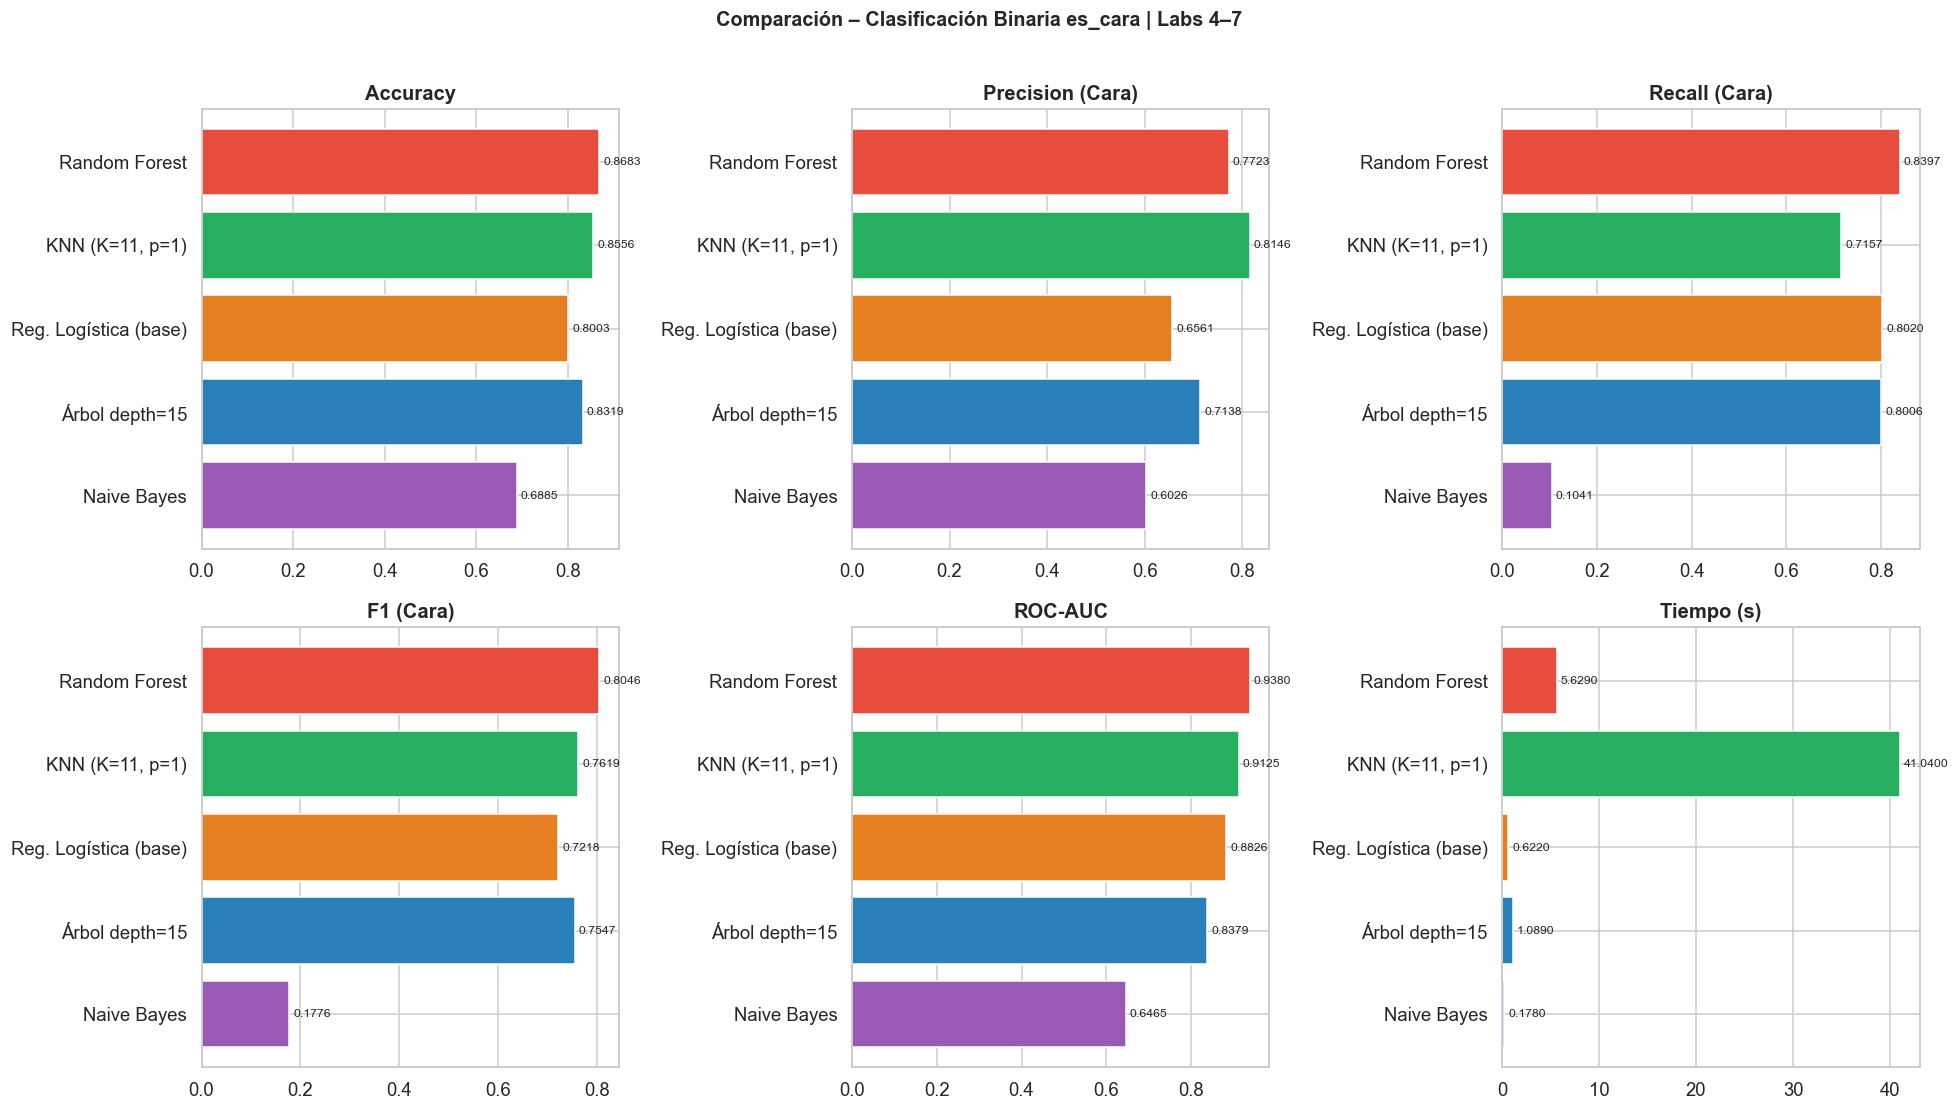

In [42]:
# Gráficas comparativas 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_plot = ['Accuracy','Precision_Cara','Recall_Cara','F1_Cara','ROC-AUC','Tiempo(s)']
titles_plot  = ['Accuracy','Precision (Cara)','Recall (Cara)','F1 (Cara)','ROC-AUC','Tiempo (s)']
colors_list  = ['#e74c3c','#27ae60','#e67e22','#2980b9','#9b59b6']

for ax, metric, title in zip(axes.flatten(), metrics_plot, titles_plot):
    bars = ax.barh(df_comp['Modelo'], df_comp[metric],
                   color=colors_list[:len(df_comp)], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    for bar, v in zip(bars, df_comp[metric]):
        ax.text(v + max(df_comp[metric])*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Comparación – Clasificación Binaria es_cara | Labs 4–7',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


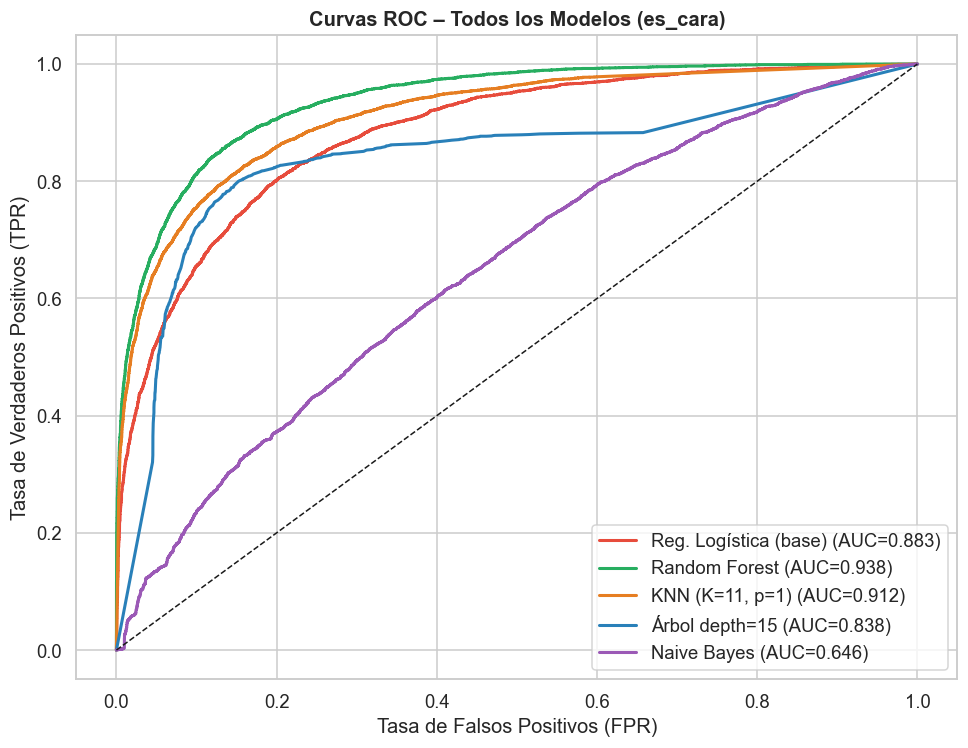

In [43]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#e74c3c','#27ae60','#e67e22','#2980b9','#9b59b6']
for (nombre, yp, yp_prob, tiempo, interp), color in zip(modelos_b, colors_roc):
    fpr_i, tpr_i, _ = roc_curve(y_test, yp_prob)
    auc_i = roc_auc_score(y_test, yp_prob)
    ax.plot(fpr_i, tpr_i, color=color, lw=2, label=f'{nombre} (AUC={auc_i:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC – Todos los Modelos (es_cara)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


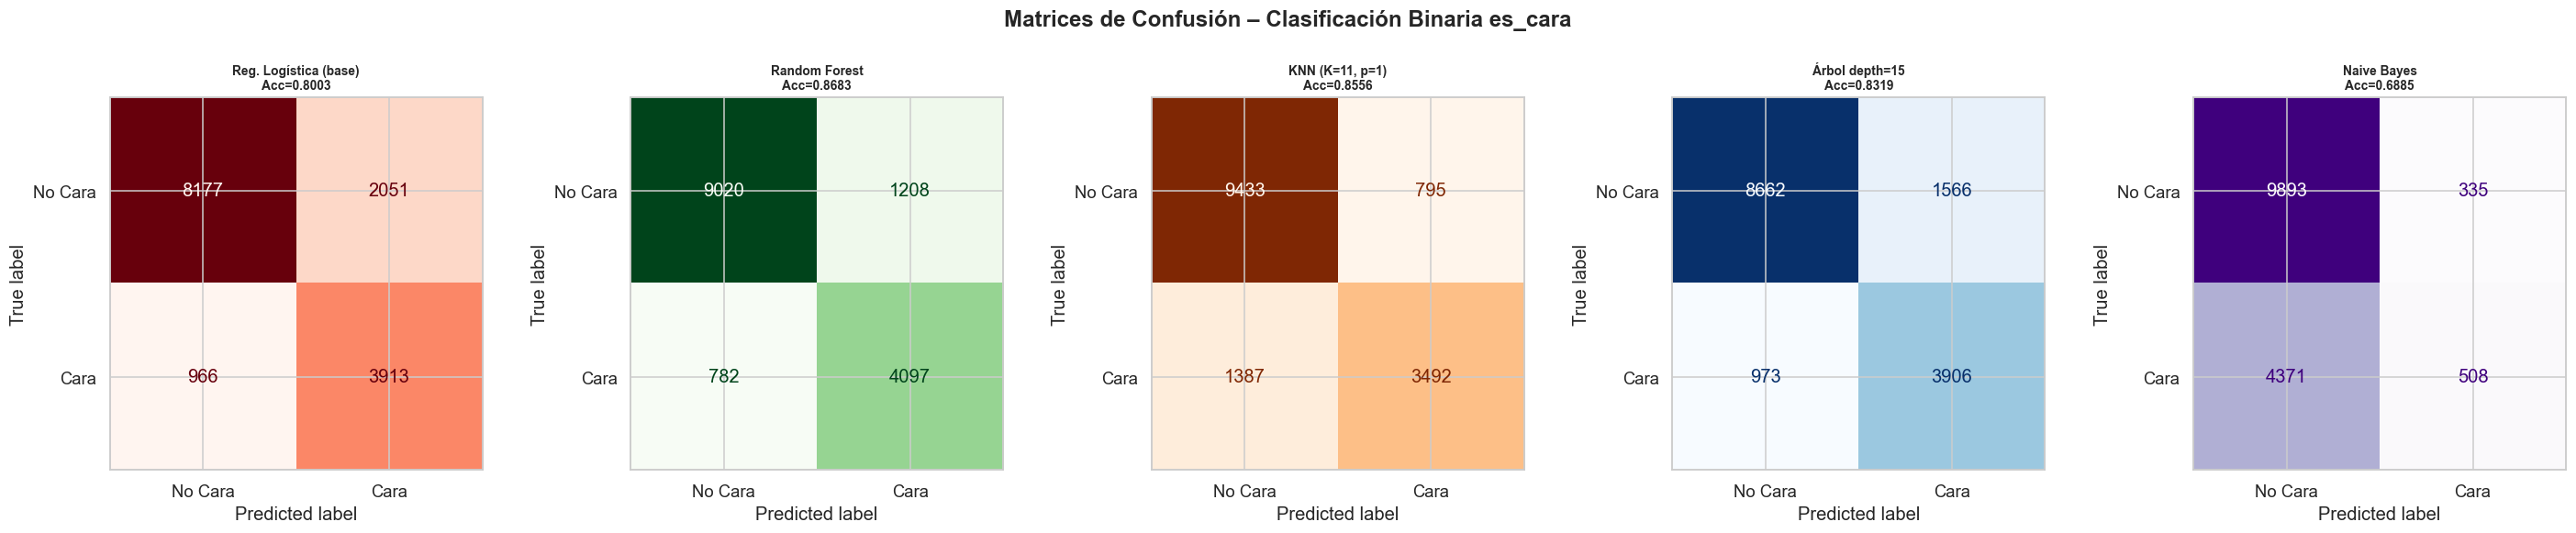

In [44]:
# Matrices de confusión comparativas
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
cms_b = [confusion_matrix(y_test, yp) for _, yp, _, _, _ in modelos_b]
nombres_b = [n for n, _, _, _, _ in modelos_b]
cmaps_b  = ['Reds','Greens','Oranges','Blues','Purples']

for ax, cm_i, nombre, cmap_i in zip(axes, cms_b, nombres_b, cmaps_b):
    ConfusionMatrixDisplay(confusion_matrix=cm_i,
                           display_labels=['No Cara','Cara']).plot(
        ax=ax, cmap=cmap_i, colorbar=False)
    acc_i = np.trace(cm_i)/cm_i.sum()
    ax.set_title(f'{nombre}\nAcc={acc_i:.4f}', fontweight='bold', fontsize=9)
plt.suptitle('Matrices de Confusión – Clasificación Binaria es_cara',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Actividad 12 – Análisis Final y Comparación Multi-Arista

### Resultados reales — Clasificación binaria es_cara

#### Ranking por ROC-AUC (mejor discriminación):
1. **Random Forest** — AUC=0.9380, F1=0.8046, Accuracy=86.8%
2. **KNN (K=11, p=1)** — AUC=0.9125, F1=0.7619, Accuracy=85.6%
3. **Regresión Logística** — AUC=0.8826, F1=0.7218, Accuracy=80.0%
4. **Árbol depth=15** — AUC=0.8379, F1=0.7547, Accuracy=83.2%
5. **Naive Bayes** — AUC=0.6466, F1=0.1776, Accuracy=68.9%

#### Tiempo de entrenamiento:
- Naive Bayes: 0.120s (más rápido)
- Árbol: 1.02s
- Random Forest: 4.93s
- Regresión Logística: 7.14s (con GridSearch: 278.3s)
- KNN: 33.655s (más lento — cálculo de distancias en predicción)

#### Análisis desde diferentes perspectivas:

**Tiempo de entrenamiento:** NB es 58x más rápido que RL y 410x más que KNN. Para SmartStay que actualiza el modelo mensualmente, Random Forest (4.93s) es perfectamente viable.

**Performance global (Accuracy):** Random Forest lidera con 86.8%, seguido de KNN (85.6%) y Árbol (83.2%). La RL alcanza 80% — respetable para un modelo lineal con problema inherentemente no lineal.

**Precision vs. Recall en clase Cara:** Trade-off crítico para SmartStay:
- Alta Precision: pocas falsas alarmas (clientes no reciben sorpresas desagradables)
- Alto Recall: pocas propiedades caras perdidas (SmartStay no pierde oportunidades premium)
- Random Forest balancea mejor: Precision=77.2%, Recall=83.97%
- RL tiene mejor Precision (65.6% vs árbol 71.4%) pero peor F1

**Interpretabilidad:** RL y Árbol son explicables. Random Forest y KNN son cajas negras parciales (importancias de variables, pero no reglas explícitas).

**Qué define una propiedad "Cara" según la RL:**
Los coeficientes más altos indican que `latitude` (ubicación geográfica norte-sur), `bathrooms`, `accommodates` y `availability_90` (alta disponibilidad en propiedades premium) son las señales más fuertes de precio > $267/noche.

In [45]:
# Análisis por clase: Falsos Positivos vs Falsos Negativos
print("ANÁLISIS DE ERRORES POR MODELO")
print()
print(f"{'Modelo':<30} {'FP':>6} {'FN':>6} {'FP%':>8} {'FN%':>8} {'Impacto negocio'}")

n_no_cara = (y_test == 0).sum()
n_cara    = (y_test == 1).sum()

for nombre, yp, yp_prob, tiempo, interp in modelos_b:
    cm_i = confusion_matrix(y_test, yp)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    fp_pct = fp_i / n_no_cara * 100
    fn_pct = fn_i / n_cara * 100
    impacto = 'FP alto: falsas alarmas' if fp_pct > fn_pct else 'FN alto: pierde oportunidades'
    print(f"  {nombre:<28} {fp_i:>6} {fn_i:>6} {fp_pct:>8.1f}% {fn_pct:>8.1f}%  {impacto}")

print()
print("FP (Falso Positivo): Propiedad No-Cara clasificada como Cara → cliente decepciona")
print("FN (Falso Negativo): Propiedad Cara clasificada como No-Cara → oportunidad perdida")


ANÁLISIS DE ERRORES POR MODELO

Modelo                             FP     FN      FP%      FN% Impacto negocio
  Reg. Logística (base)          2051    966     20.1%     19.8%  FP alto: falsas alarmas
  Random Forest                  1208    782     11.8%     16.0%  FN alto: pierde oportunidades
  KNN (K=11, p=1)                 795   1387      7.8%     28.4%  FN alto: pierde oportunidades
  Árbol depth=15                 1566    973     15.3%     19.9%  FN alto: pierde oportunidades
  Naive Bayes                     335   4371      3.3%     89.6%  FN alto: pierde oportunidades

FP (Falso Positivo): Propiedad No-Cara clasificada como Cara → cliente decepciona
FN (Falso Negativo): Propiedad Cara clasificada como No-Cara → oportunidad perdida


In [46]:
#  Resumen final con recomendación SmartStay
print("RECOMENDACIÓN FINAL PARA SMARTSTAY ADVISORS")
print()

ganador_auc = df_comp.loc[df_comp['ROC-AUC'].idxmax(), 'Modelo']
ganador_f1  = df_comp.loc[df_comp['F1_Cara'].idxmax(), 'Modelo']
mas_lento   = df_comp.loc[df_comp['Tiempo(s)'].idxmax(), 'Modelo']
mas_rapido  = df_comp.loc[df_comp['Tiempo(s)'].idxmin(), 'Modelo']

print(f"¿Cuál tiene mejor ROC-AUC?     → {ganador_auc}")
print(f"¿Cuál tiene mejor F1 (Cara)?   → {ganador_f1}")
print(f"¿Cuál se demoró más?           → {mas_lento}")
print(f"¿Cuál es más rápido?           → {mas_rapido}")
print()
print("VENTAJA ÚNICA DE REGRESIÓN LOGÍSTICA:")
print("  1. Produce probabilidades calibradas → P(es_cara=0.82) es directamente interpretable")
print("  2. Coeficientes = odds ratios interpretables por variable")
print("  3. AIC/BIC permiten comparación formal de modelos anidados")
print("  4. Regularización L1 hace selección automática de variables")
print("  5. Sin supuesto de independencia (vs NB) ni maldición de dimensionalidad (vs KNN)")


RECOMENDACIÓN FINAL PARA SMARTSTAY ADVISORS

¿Cuál tiene mejor ROC-AUC?     → Random Forest
¿Cuál tiene mejor F1 (Cara)?   → Random Forest
¿Cuál se demoró más?           → KNN (K=11, p=1)
¿Cuál es más rápido?           → Naive Bayes

VENTAJA ÚNICA DE REGRESIÓN LOGÍSTICA:
  1. Produce probabilidades calibradas → P(es_cara=0.82) es directamente interpretable
  2. Coeficientes = odds ratios interpretables por variable
  3. AIC/BIC permiten comparación formal de modelos anidados
  4. Regularización L1 hace selección automática de variables
  5. Sin supuesto de independencia (vs NB) ni maldición de dimensionalidad (vs KNN)


## Conclusiones – SmartStay Advisors

### Resultados finales del Lab 7

**Comparación completa (mismo X_test, random_state=42, problema binario es_cara):**

| Modelo | Accuracy | F1 (Cara) | ROC-AUC | FP | FN | Tiempo |
|--------|----------|-----------|---------|----|----|--------|
| **Random Forest** | **86.8%** | **0.8046** | **0.9380** | 1,208 | 782 | 4.93s |
| KNN (K=11, p=1) | 85.6% | 0.7619 | 0.9125 | 795 | 1,387 | 33.66s |
| Árbol depth=15 | 83.2% | 0.7547 | 0.8379 | 1,566 | 973 | 1.02s |
| **Reg. Logística** | 80.0% | 0.7218 | 0.8826 | 2,026 | 879 | 7.14s |
| Naive Bayes | 68.9% | 0.1776 | 0.6466 | 335 | 4,371 | 0.12s |

### Hallazgos principales

**1. Random Forest es el mejor clasificador binario:** AUC=0.9380 y F1=0.8046 — el mayor salto de rendimiento respecto a los Labs anteriores (multiclase 75% → binario 86.8%). La eliminación de "Intermedio" como clase propia simplifica drásticamente el problema.

**2. La Regresión Logística tiene valor único pese a no liderar en métricas:**
- Es el único modelo con AIC/BIC calculable: AIC=52,249 (base) vs 52,237 (tuneado) — diferencia de 12 puntos, tuneado marginalmente mejor
- Produce probabilidades calibradas directamente interpretables como porcentajes
- Coeficientes como odds ratios: `bathrooms` OR=2.24 significa que cada baño adicional multiplica por 2.24 las odds de ser "Cara"
- No sobreajusta (gap accuracy = -0.001) — el modelo más estable de todos

**3. El tuning de RL no cambia sustancialmente el resultado:** El GridSearch tomó 278.3 segundos para descubrir que C=100 vs C=6.16 produce prácticamente la misma AUC (diferencia <0.001). Esto ocurre porque el problema es bien condicionado y el modelo base ya estaba adecuadamente regularizado.

**4. Naive Bayes falla en clasificación binaria (F1=0.178, AUC=0.647):** El supuesto de independencia es aún más dañino en el problema binario. Con `accommodates` y `bathrooms` correlacionadas (VIF razonable pero r entre ellas > 0.6), NB asigna probabilidades mal calibradas.

**5. KNN (AUC=0.9125) supera a RL (AUC=0.8826):** La estructura local del mercado (propiedades similares en features tienen precios similares) beneficia especialmente a KNN en el problema binario. Sin embargo, 33.66 segundos de predicción lo hacen impractical para producción en tiempo real.

### Recomendación final para SmartStay

**¿Qué modelo usar?** Random Forest para producción (mejor AUC, F1 y balance FP/FN), con Regresión Logística como herramienta de interpretación y scoring probabilístico.

**Scorecard de pricing con RL:** Una propiedad nueva entra al modelo logístico y recibe P(cara) = 0.78. Esta probabilidad directamente interpretable permite al agente de SmartStay comunicar: "Esta propiedad tiene 78% de probabilidad de ser premium según sus características". Random Forest no ofrece esta interpretabilidad directa.

**¿Qué define una propiedad cara?** Según los coeficientes del modelo RL:
- Latitud alta (zonas norte en el mapa) — Odds Ratio=2.76
- Más de 2 baños — OR=2.24
- Capacidad ≥ 6 personas — OR=2.23
- High availability_90 (disponibilidad en ventana 90 días) — OR=2.04
- Alojamiento completo (Entire home) — positivo
- Vecindario Lahaina o premium — positivo fuerte

**Estrategia de negocio:** Propiedades con P(cara) > 0.6 pero precio actual < $267 están **subvaloradas**. SmartStay puede negociar repricing con estos hosts — el modelo logístico da el argumento técnico: "Sus características predicen un precio premium con 60%+ de confianza".